
# 02 — Parameter Landscape: Sensitivity & Correlation Analysis

This notebook explores the SDGFT parameter space through:
1. **χ² heatmaps** — Where does the model best fit experiment?
2. **Observable sensitivity maps** — How do observables depend on (Δ, δ_g)?
3. **Correlation matrix** — Which observables co-vary across the landscape?
4. **1D profiles** — Marginal χ² as a function of each parameter

> **Oracle Database DOI:** [10.5281/zenodo.18863347](https://doi.org/10.5281/zenodo.18863347)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from sdgft_ml.inference import OracleDB, SDGFTPredictor

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

db = OracleDB()
print(db.summary())

/home/david/Coding/sdgft/sdgft-ml-toolkit/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SDGFT Oracle Database
  Rows:       61,701,488
  Columns:    44
  Δ range:    [0.204400, 0.216900]
  δ_g range:  [0.040000, 0.043000]
  Gold Std:   35,021,095
  Best χ²:    16.9696
  File:       /home/david/Coding/sdgft/sdgft-ml-toolkit/data/oracle_db.parquet
  Size:       3.41 GB


## 1. χ² Heatmap

The Oracle stores the minimum total χ² for each (Δ, δ_g) bin.

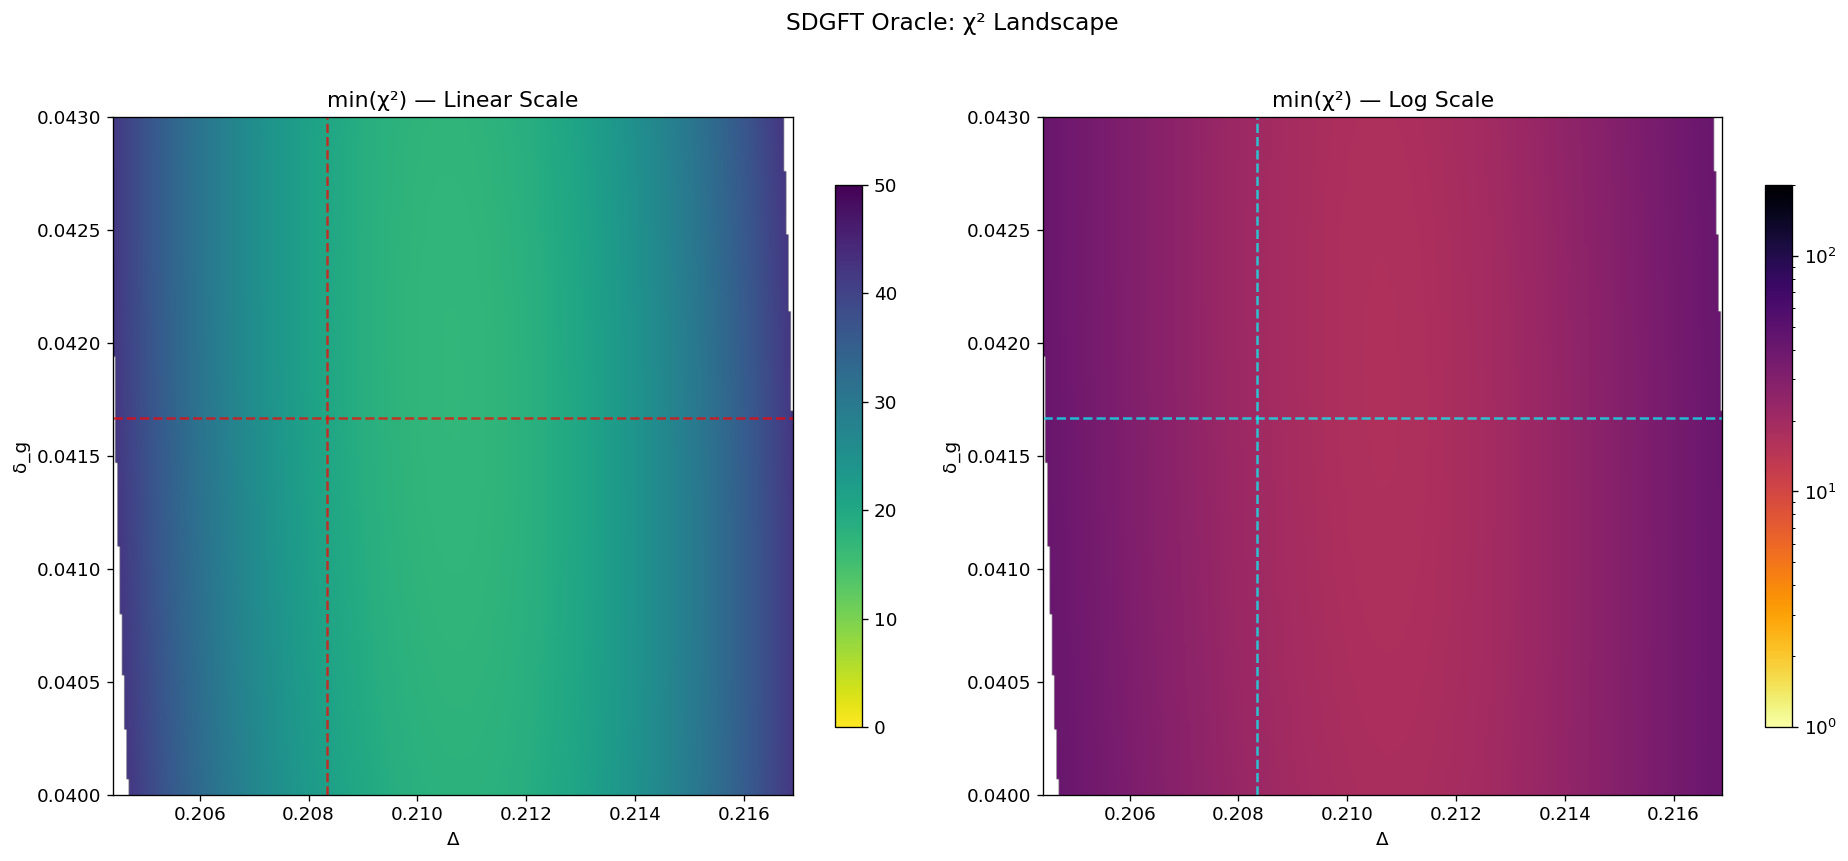

In [2]:
grid, d_edges, dg_edges = db.chi2_heatmap(bins=300)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Linear scale
im0 = axes[0].imshow(
    grid.T, origin="lower", aspect="auto",
    extent=[d_edges[0], d_edges[-1], dg_edges[0], dg_edges[-1]],
    cmap="viridis_r", vmin=0, vmax=50,
)
axes[0].set_xlabel("Δ")
axes[0].set_ylabel("δ_g")
axes[0].set_title("min(χ²) — Linear Scale")
axes[0].axvline(5/24, color='r', ls='--', alpha=0.7)
axes[0].axhline(1/24, color='r', ls='--', alpha=0.7)
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# Log scale
grid_log = np.where(grid > 0, grid, np.nan)
im1 = axes[1].imshow(
    grid_log.T, origin="lower", aspect="auto",
    extent=[d_edges[0], d_edges[-1], dg_edges[0], dg_edges[-1]],
    cmap="inferno_r", norm=LogNorm(vmin=1, vmax=200),
)
axes[1].set_xlabel("Δ")
axes[1].set_ylabel("δ_g")
axes[1].set_title("min(χ²) — Log Scale")
axes[1].axvline(5/24, color='cyan', ls='--', alpha=0.7)
axes[1].axhline(1/24, color='cyan', ls='--', alpha=0.7)
plt.colorbar(im1, ax=axes[1], shrink=0.8)

fig.suptitle("SDGFT Oracle: χ² Landscape", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2. Observable Sensitivity Maps

For each observable, we compute the mean value in each (Δ, δ_g) bin to see
how it varies across the parameter landscape.

In [3]:
def binned_mean_map(db, observable, bins=200):
    """Compute binned mean of an observable over (Δ, δ_g)."""
    d = db.df["delta"].values
    dg = db.df["delta_g"].values
    vals = db.df[observable].values

    d_edges = np.linspace(d.min(), d.max(), bins + 1)
    dg_edges = np.linspace(dg.min(), dg.max(), bins + 1)

    i_d = np.clip(np.digitize(d, d_edges) - 1, 0, bins - 1)
    i_dg = np.clip(np.digitize(dg, dg_edges) - 1, 0, bins - 1)

    grid_sum = np.zeros((bins, bins), dtype=np.float64)
    grid_cnt = np.zeros((bins, bins), dtype=np.int64)

    np.add.at(grid_sum, (i_d, i_dg), vals)
    np.add.at(grid_cnt, (i_d, i_dg), 1)

    grid = np.where(grid_cnt > 0, grid_sum / grid_cnt, np.nan)
    return grid, d_edges, dg_edges

/tmp/ipykernel_87591/3203459612.py:19: RuntimeWarning: invalid value encountered in divide
  grid = np.where(grid_cnt > 0, grid_sum / grid_cnt, np.nan)


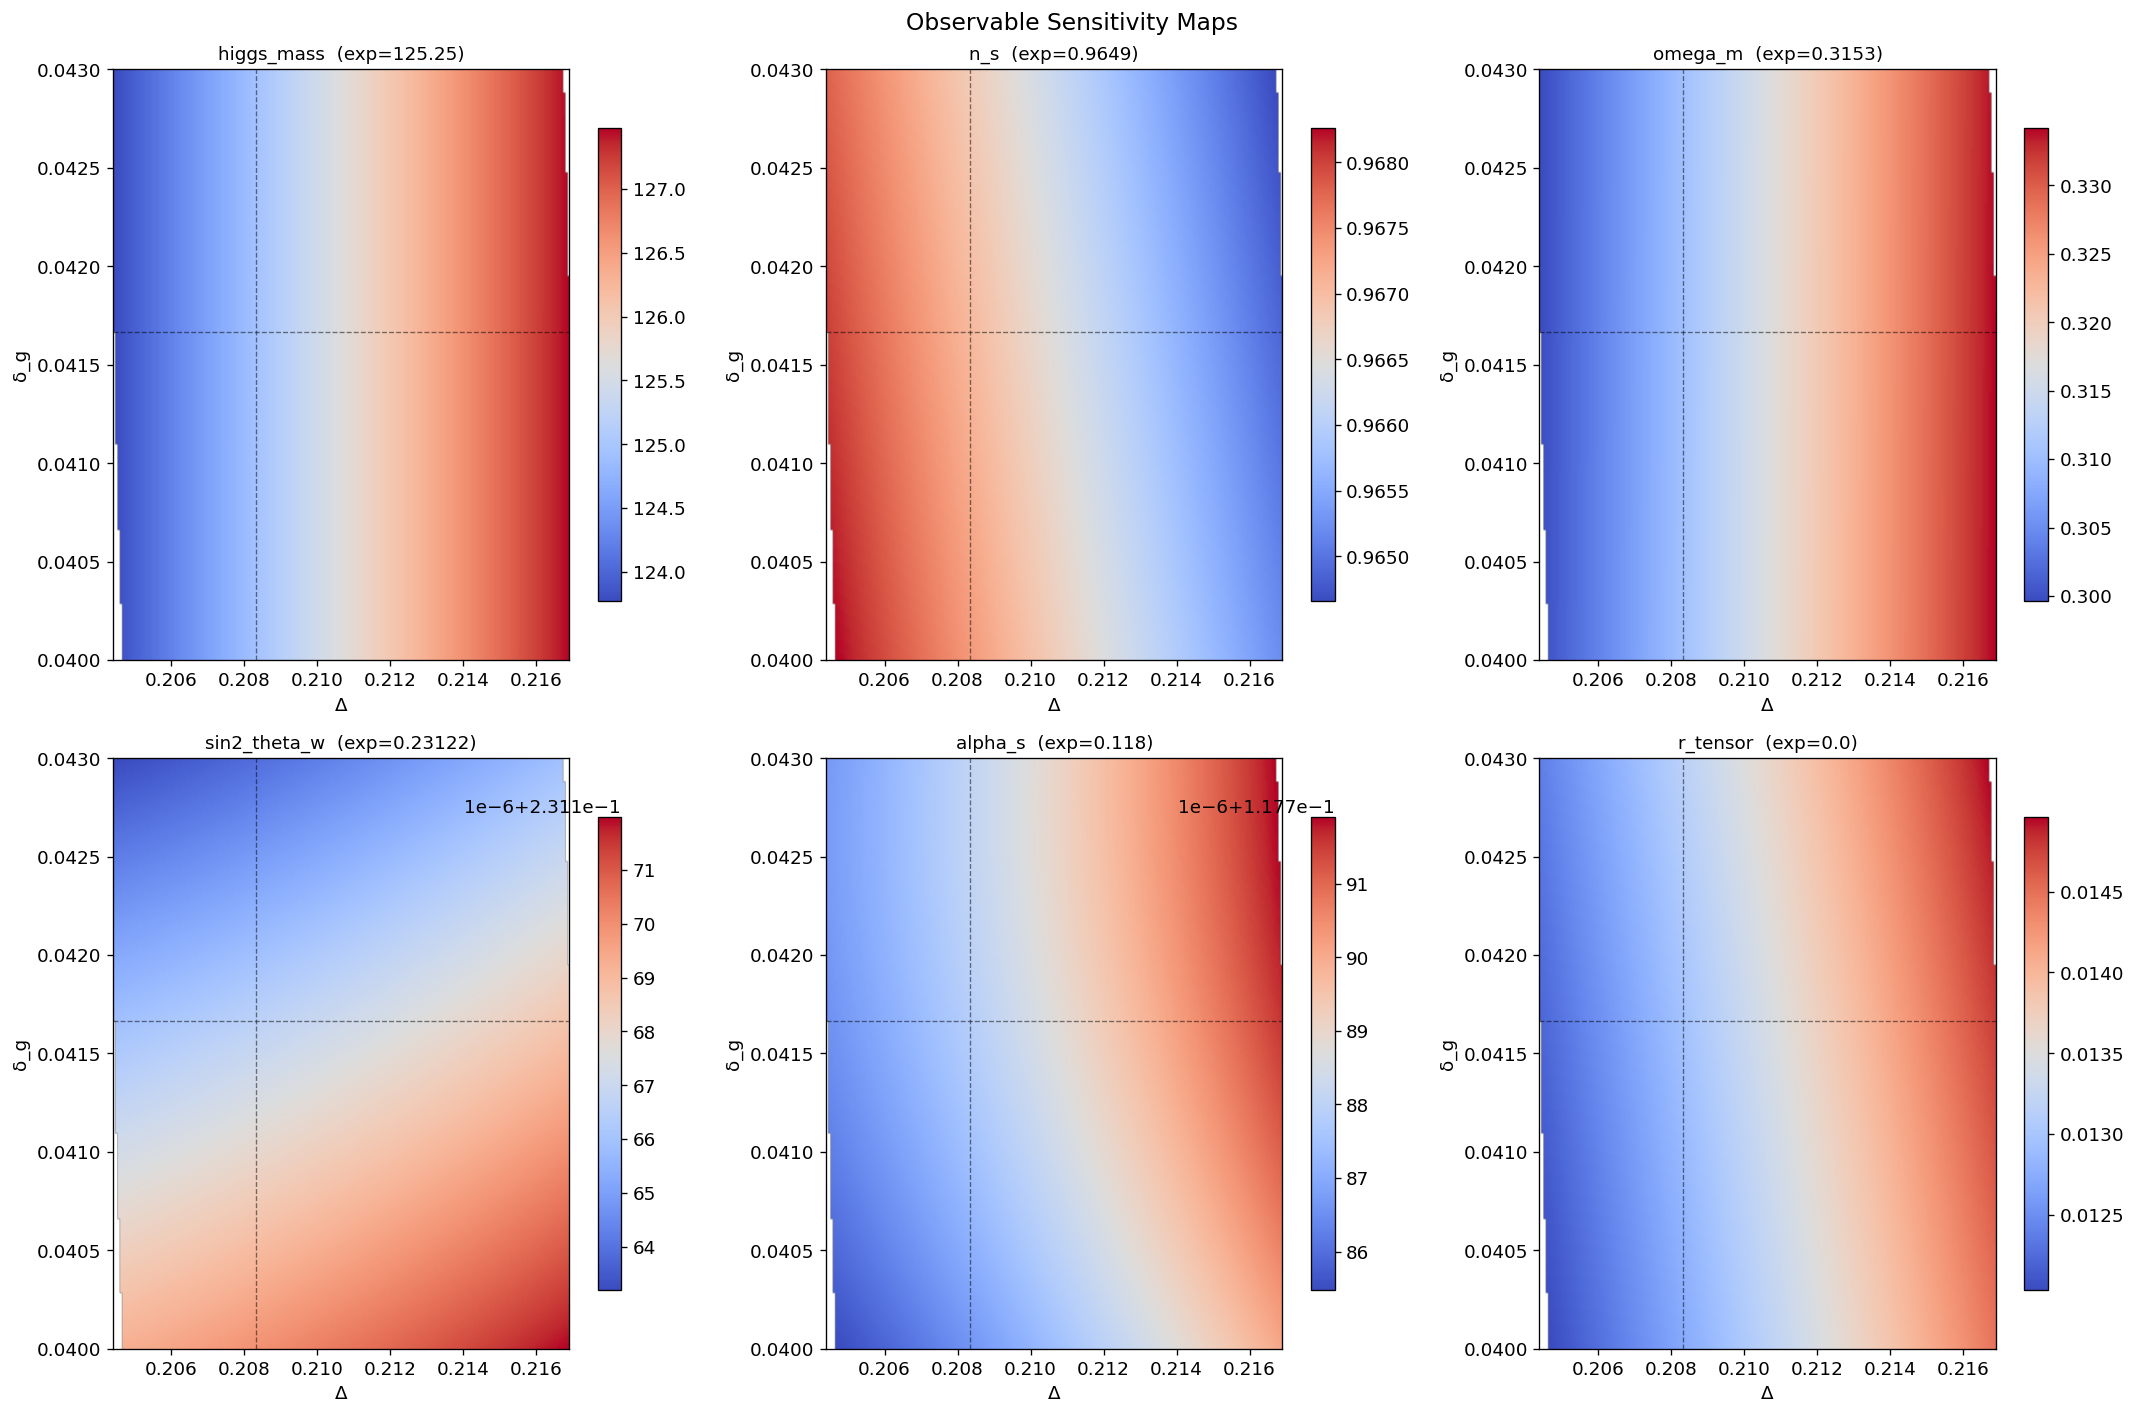

In [4]:
obs_list = ["higgs_mass", "n_s", "omega_m", "sin2_theta_w", "alpha_s", "r_tensor"]
exp_values = {
    "higgs_mass": 125.25, "n_s": 0.9649, "omega_m": 0.3153,
    "sin2_theta_w": 0.23122, "alpha_s": 0.1180, "r_tensor": 0.0,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, obs in zip(axes.flat, obs_list):
    grid, d_edges, dg_edges = binned_mean_map(db, obs, bins=200)
    im = ax.imshow(
        grid.T, origin="lower", aspect="auto",
        extent=[d_edges[0], d_edges[-1], dg_edges[0], dg_edges[-1]],
        cmap="coolwarm",
    )
    ax.set_xlabel("Δ")
    ax.set_ylabel("δ_g")
    ax.set_title(f"{obs}  (exp={exp_values.get(obs, '?')})", fontsize=11)
    ax.axvline(5/24, color='k', ls='--', lw=0.8, alpha=0.5)
    ax.axhline(1/24, color='k', ls='--', lw=0.8, alpha=0.5)
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle("Observable Sensitivity Maps", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Observable Correlation Matrix

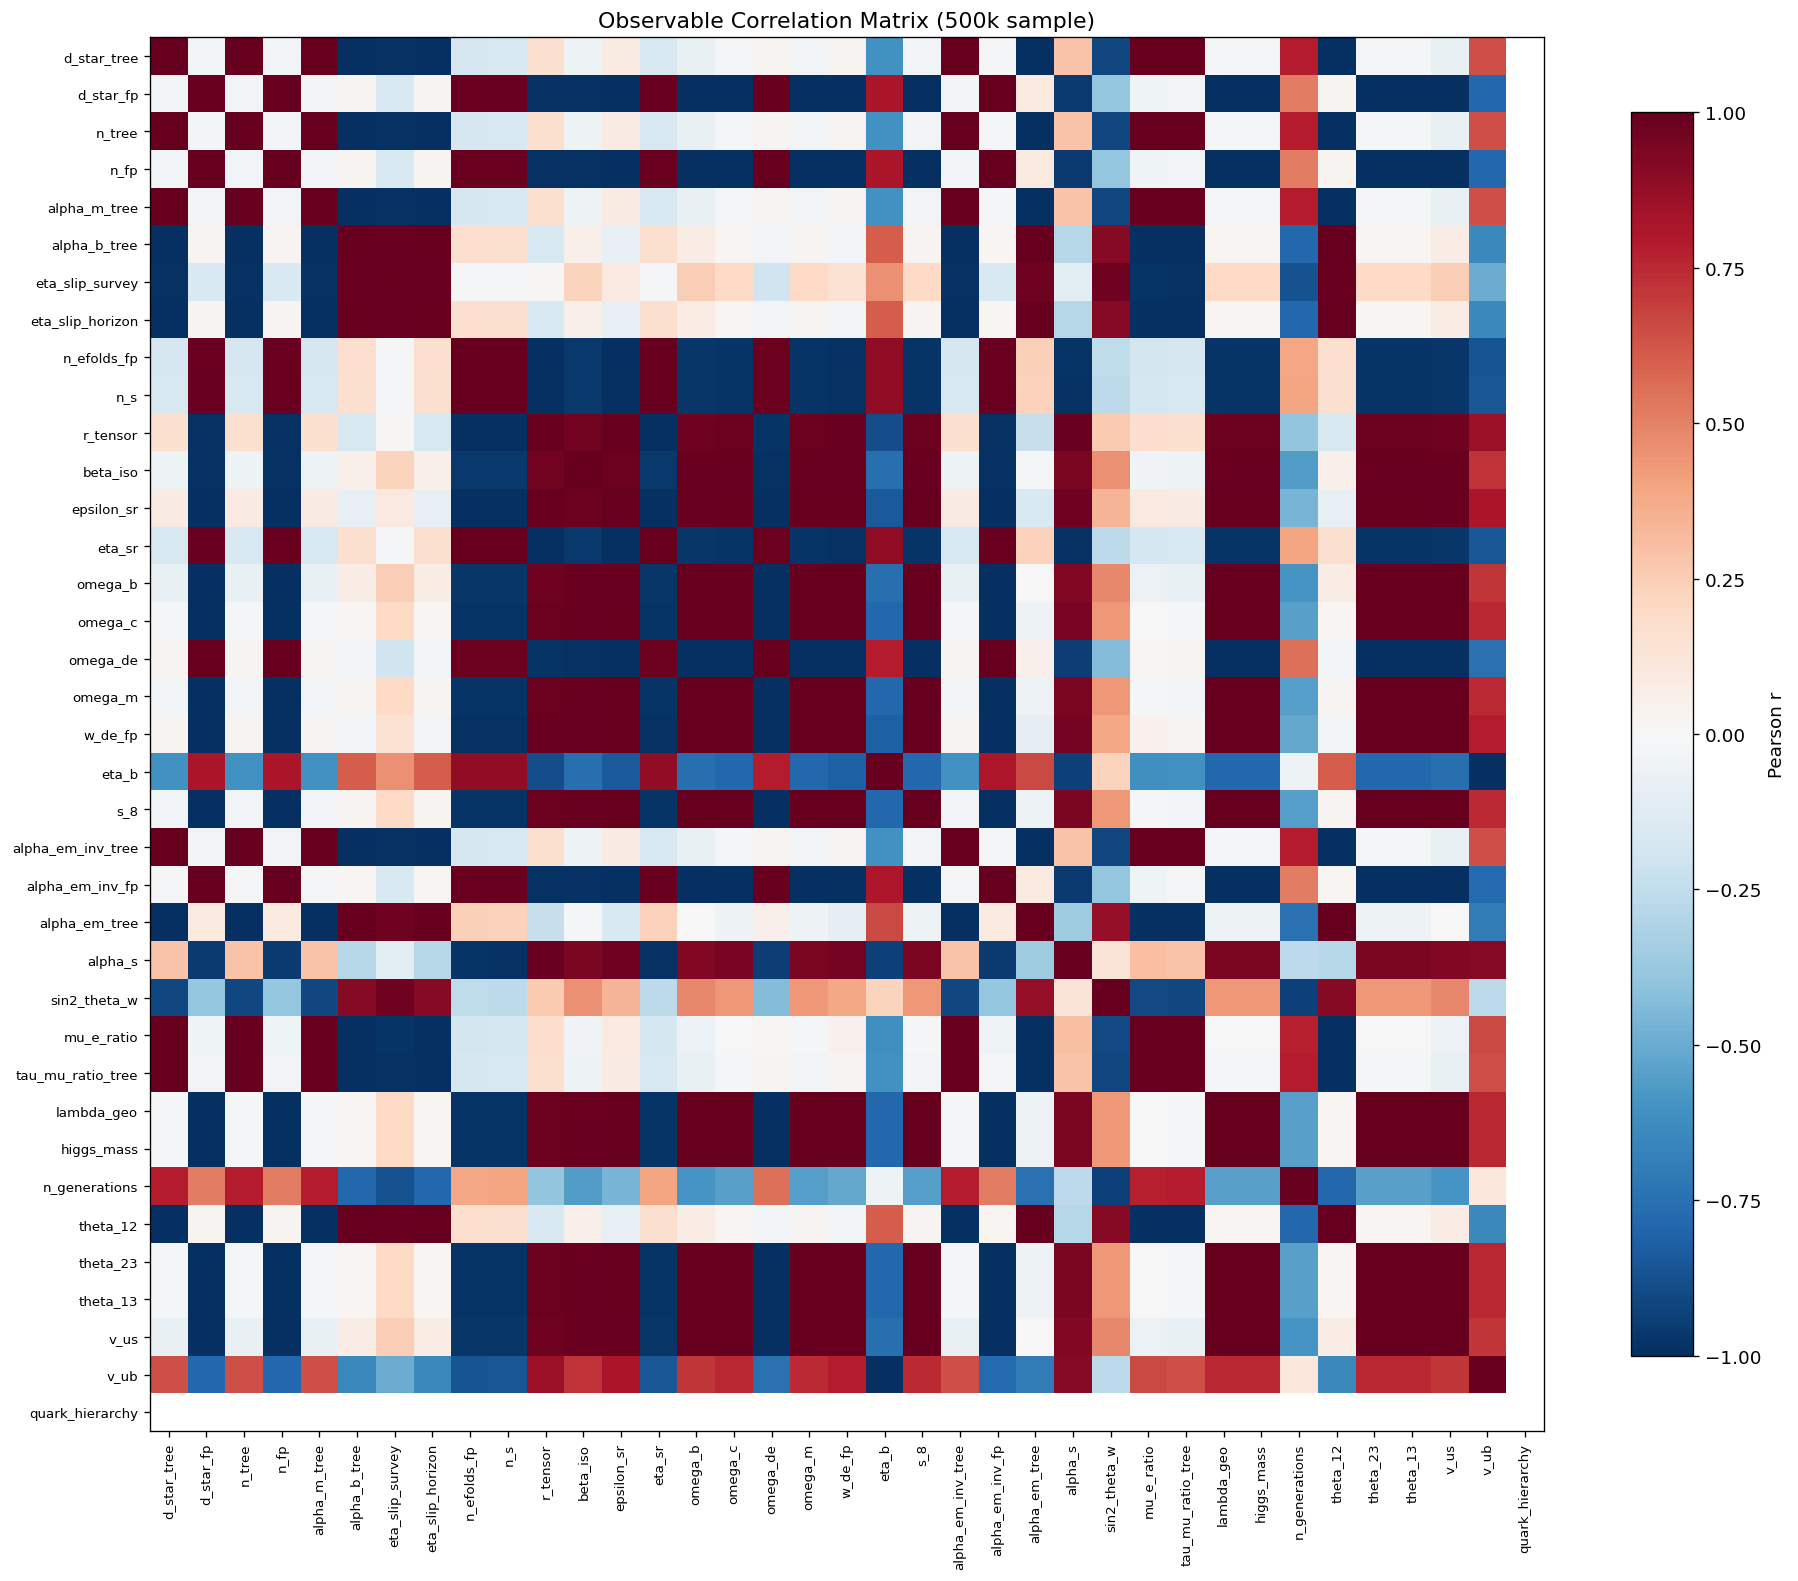

In [5]:
# Sample for speed (correlation on 61M rows is slow)
sample = db.df.sample(n=min(500_000, len(db.df)), random_state=42)

# Select observables (exclude metadata columns)
meta_cols = {"delta", "delta_g", "total_chi2", "chi2_per_dof",
             "n_tensions", "gold_standard", "desi_w_match"}
obs_cols = [c for c in sample.columns if c not in meta_cols]

corr = sample[obs_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(obs_cols)))
ax.set_yticks(range(len(obs_cols)))
ax.set_xticklabels(obs_cols, rotation=90, fontsize=8)
ax.set_yticklabels(obs_cols, fontsize=8)
ax.set_title("Observable Correlation Matrix (500k sample)")
plt.colorbar(im, shrink=0.8, label="Pearson r")
plt.tight_layout()
plt.show()

In [6]:
# Top correlated pairs (absolute, off-diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_pairs = (
    corr.where(mask)
    .stack()
    .reset_index()
    .rename(columns={"level_0": "obs_1", "level_1": "obs_2", 0: "corr"})
)
corr_pairs["abs_corr"] = corr_pairs["corr"].abs()

print("Top 15 correlated observable pairs:")
display(corr_pairs.nlargest(15, "abs_corr")[["obs_1", "obs_2", "corr"]])

Top 15 correlated observable pairs:


,obs_1,obs_2,corr
1217,theta_23,theta_13,1.0
40,d_star_fp,n_fp,1.0
101,n_tree,tau_mu_ratio_tree,1.0
27,d_star_tree,tau_mu_ratio_tree,1.0
2,d_star_tree,n_tree,1.0
155,alpha_m_tree,eta_slip_horizon,-1.0
1068,lambda_geo,theta_23,1.0
153,alpha_m_tree,alpha_b_tree,-1.0
21,d_star_tree,alpha_em_inv_tree,1.0
1069,lambda_geo,theta_13,1.0


## 4. 1D Marginal χ² Profiles

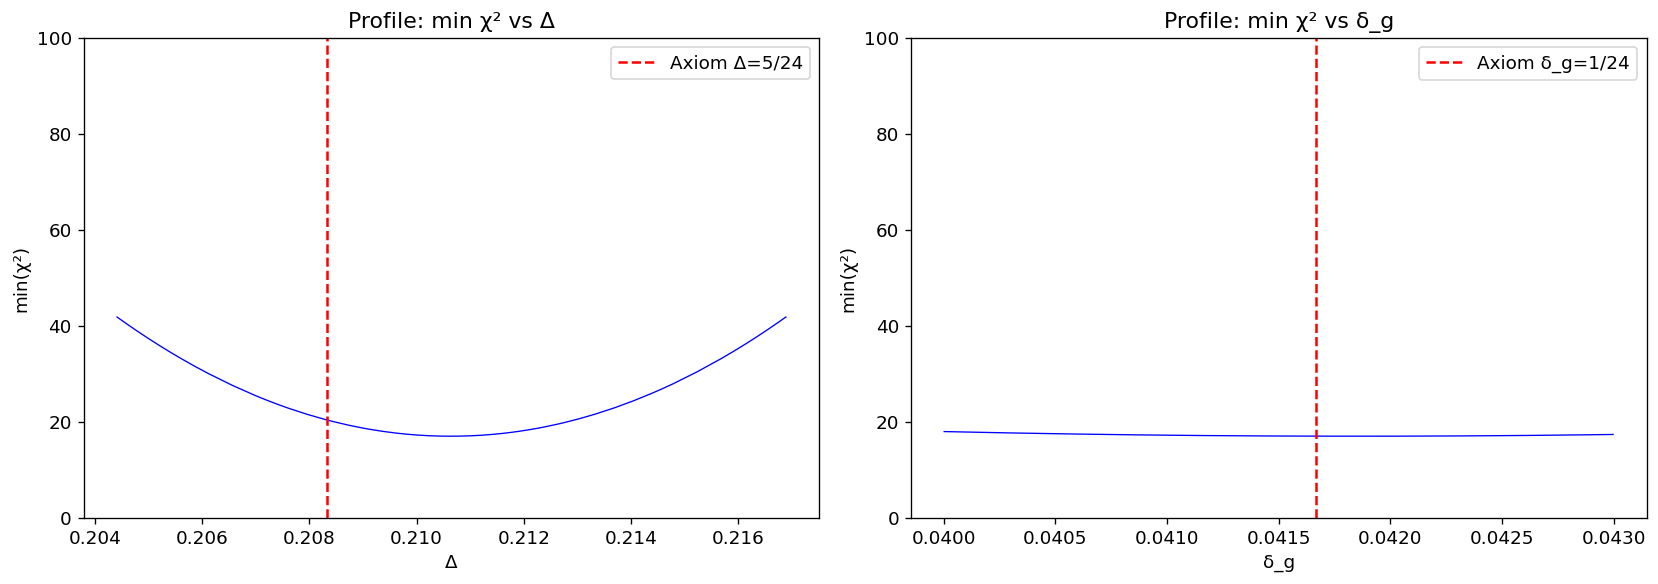

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bins_d = 500

# --- Profile over Δ (vectorized) ---
d_vals = db.df["delta"].values
chi2_vals = db.df["total_chi2"].values
d_bins = np.linspace(d_vals.min(), d_vals.max(), bins_d + 1)
d_idx = np.clip(np.digitize(d_vals, d_bins) - 1, 0, bins_d - 1)

d_min_chi2 = pd.DataFrame({"bin": d_idx, "chi2": chi2_vals}).groupby("bin")["chi2"].min()
d_profile = np.full(bins_d, np.nan)
d_profile[d_min_chi2.index.values] = d_min_chi2.values

d_centers = 0.5 * (d_bins[:-1] + d_bins[1:])
ax1.plot(d_centers, d_profile, 'b-', lw=0.8)
ax1.axvline(5/24, color='r', ls='--', label='Axiom Δ=5/24')
ax1.set_xlabel("Δ")
ax1.set_ylabel("min(χ²)")
ax1.set_title("Profile: min χ² vs Δ")
ax1.legend()
ax1.set_ylim(0, 100)

# --- Profile over δ_g (vectorized) ---
dg_vals = db.df["delta_g"].values
dg_bins = np.linspace(dg_vals.min(), dg_vals.max(), bins_d + 1)
dg_idx = np.clip(np.digitize(dg_vals, dg_bins) - 1, 0, bins_d - 1)

dg_min_chi2 = pd.DataFrame({"bin": dg_idx, "chi2": chi2_vals}).groupby("bin")["chi2"].min()
dg_profile = np.full(bins_d, np.nan)
dg_profile[dg_min_chi2.index.values] = dg_min_chi2.values

dg_centers = 0.5 * (dg_bins[:-1] + dg_bins[1:])
ax2.plot(dg_centers, dg_profile, 'b-', lw=0.8)
ax2.axvline(1/24, color='r', ls='--', label='Axiom δ_g=1/24')
ax2.set_xlabel("δ_g")
ax2.set_ylabel("min(χ²)")
ax2.set_title("Profile: min χ² vs δ_g")
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 5. Parameter Sensitivity via the GNN Predictor

Use the GNN directly to compute fine-grained sensitivity at the axiom point.

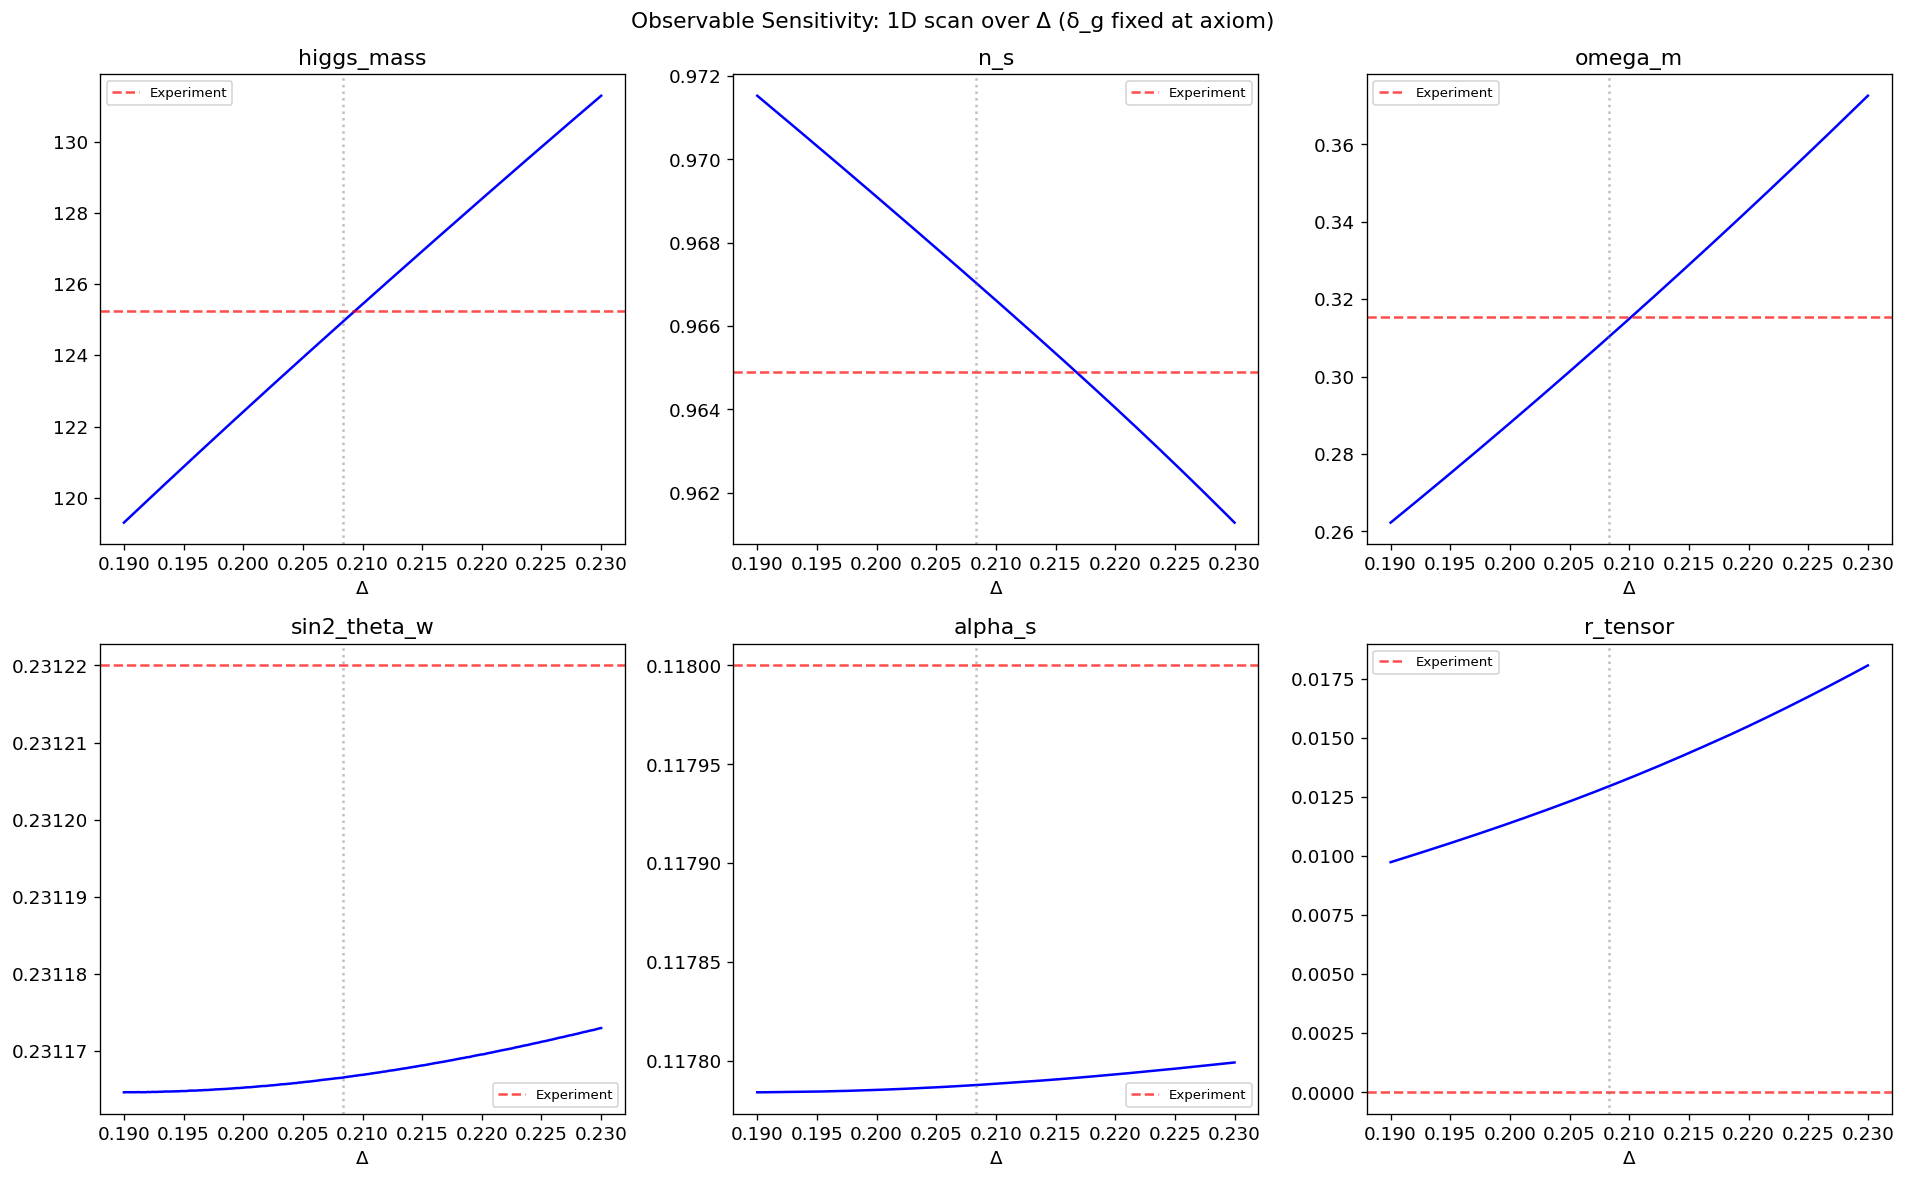

In [8]:
predictor = SDGFTPredictor()

# 1D scan: vary Δ around axiom
delta_axiom = 5 / 24
delta_g_axiom = 1 / 24

deltas = np.linspace(0.19, 0.23, 200)
params_scan = np.column_stack([deltas, np.full_like(deltas, delta_g_axiom)])
df_scan = predictor.predict_batch(params_scan)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, obs in zip(axes.flat, obs_list):
    ax.plot(deltas, df_scan[obs].values, 'b-', lw=1.5)
    if obs in exp_values:
        ax.axhline(exp_values[obs], color='r', ls='--', alpha=0.7, label="Experiment")
    ax.axvline(delta_axiom, color='gray', ls=':', alpha=0.5)
    ax.set_xlabel("Δ")
    ax.set_title(obs)
    ax.legend(fontsize=8)

fig.suptitle("Observable Sensitivity: 1D scan over Δ (δ_g fixed at axiom)", fontsize=13)
plt.tight_layout()
plt.show()

---

**Next:** [03 Experimental Validation](03_experimental_validation.ipynb) — Full 22-observable scorecard with pull distributions